## Контекст

Вы анализируете результаты двух A/B-тестов в сервисе доставки готовых продуктов.

**Тест 1. Формат фотографий блюд.** Пользователям показывали фотографии в трёх форматах:
- **A** — прямоугольные 16:9;
- **B** — квадратные;
- **C** — прямоугольные 12:4.

**Тест 2. Кнопка заказа.** Пользователей разделили на контрольную и тестовую группы: одной группе показывали текущую версию кнопки, другой — новую. Дополнительно пользователи разделены на два клиентских сегмента: high и low.

Задача анализа — проверить, есть ли статистически значимые различия между вариантами, оценить их размер и на основании результатов сформулировать продуктовые выводы.

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats
import statsmodels.formula.api as smf
from statsmodels.stats.api import anova_lm
import pingouin as pg

In [3]:
# Загружаем данные
task_1 = pd.read_csv('5_task_1.csv')
task_1.head()

,id,group,events
0,16046,A,14
1,18712,A,41
2,3268,A,30
3,22633,A,37
4,28071,A,38


**Гипотезы:**

- **H0:** среднее количество заказов одинаково во всех трёх группах.
- **H1:** хотя бы в одной группе среднее количество заказов отличается.

<Axes: xlabel='events'>

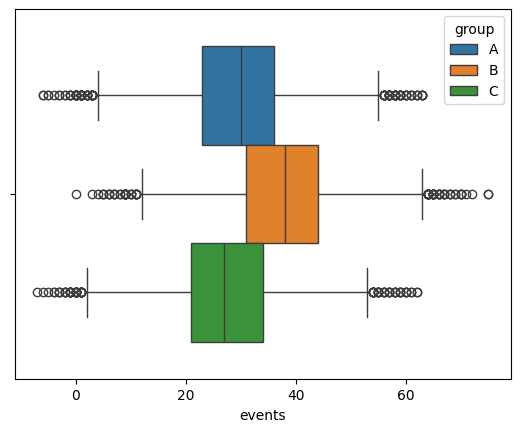

In [4]:
# Сравниваем распределения групп визуально

sns.boxplot(data=task_1, x='events', hue='group')

На графике видно, что средние значения отличаются, а внутри групп есть заметный разброс. Перед применением ANOVA проверим, насколько различаются дисперсии групп.

In [5]:
# Сравниваем стандартные отклонения групп
task_1.groupby('group').events.std()

group
A    10.079376
B     9.848360
C     9.959048
Name: events, dtype: float64

Стандартные отклонения немного различаются. Проверим статистически, достаточно ли этого различия, чтобы считать дисперсии групп неодинаковыми.

In [6]:
# Проверяем равенство дисперсий с помощью теста Левина
stats.levene(task_1[task_1.group == 'A'].events, task_1[task_1.group == 'B'].events, task_1[task_1.group == 'C'].events)

LeveneResult(statistic=np.float64(2.2622596339318033), pvalue=np.float64(0.10413271994973812))

**Результат теста Левина:** p-value > 0.05. Статистически значимых различий в дисперсиях групп не обнаружено. Условие для применения ANOVA выполняется.


Проверим распределение данных на нормальность — это одно из условий применения классической ANOVA.

In [7]:
is_normal_group_A = stats.normaltest(task_1[task_1.group == 'A'].events)
is_normal_group_B = stats.normaltest(task_1[task_1.group == 'B'].events)
is_normal_group_C = stats.normaltest(task_1[task_1.group == 'C'].events)

print(f'''тесты Д'Агостино Пирсона
{is_normal_group_A}
{is_normal_group_B}
{is_normal_group_C}
''')

тесты Д'Агостино Пирсона
NormaltestResult(statistic=np.float64(2.1034599402238734), pvalue=np.float64(0.3493328906085719))
NormaltestResult(statistic=np.float64(0.8410715800223014), pvalue=np.float64(0.6566948749848232))
NormaltestResult(statistic=np.float64(3.2437258090547583), pvalue=np.float64(0.1975303758831277))



**Результат:** p-value > 0.05. Статистически значимых отклонений от нормального распределения не обнаружено.

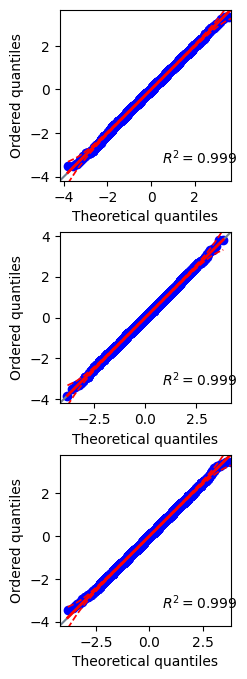

In [31]:
# построим qqplot, показывающий, насколько распределения близки к нормальному
fig, axes = plt.subplots(3, 1, figsize=(8,8),)
pg.qqplot(task_1[task_1.group == 'A'].events, dist='norm', ax=axes[0])
pg.qqplot(task_1[task_1.group == 'B'].events, dist='norm', ax=axes[1])
pg.qqplot(task_1[task_1.group == 'C'].events, dist='norm', ax=axes[2])

plt.subplots_adjust(hspace=0.3)

In [ ]:
Данные распределены в прямую линию, следовательно распределения близки к нормальному.

In [9]:
# Выполняем однофакторный ANOVA-тест через scipy.stats
groups = ['A', 'B', 'C']

samples = [task_1[task_1.group == g].events for g in groups]

f_stat, p_value = stats.f_oneway(*samples)
print(f"F = {f_stat:.3f}, p = {p_value:.5f}")

F = 2886.167, p = 0.00000


In [10]:
# Повторяем ANOVA с помощью библиотеки Pingouin
import pingouin as pg

aov = pg.anova(data=task_1, dv='events', between='group')
aov

,Source,ddof1,ddof2,F,p_unc,np2
0,group,2,29997,2886.166657,0.0,0.161377


In [11]:
test_tukey = pg.pairwise_tukey(data=task_1, dv='events', between='group') #dependent variables
test_tukey

,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges
0,A,B,29.5796,37.6136,-8.0340,0.140894,-57.021604,0.0,-0.806229
1,A,C,29.5796,27.4703,2.1093,0.140894,14.970833,0.0,0.210514
2,B,C,37.6136,27.4703,10.1433,0.140894,71.992436,0.0,1.024138


**Результат теста:** средние значения между вариантами статистически значимо различаются.

Вариант **B — квадратные фотографии** показывает наибольшее среднее количество заказов. Для дальнейшего тестирования и принятия продуктового решения этот вариант можно рассматривать как основной кандидат.

## Тест 2. Новая версия кнопки заказа

В эксперименте сравниваем текущую и новую версии кнопки заказа. Дополнительно анализируем результаты отдельно для двух клиентских сегментов: **high** и **low**.

Цель — понять, меняется ли количество заказов после редизайна кнопки и одинаково ли работает изменение для разных сегментов.

In [12]:
task_2 = pd.read_csv('5_task_2.csv')
task_2.head()

,id,group,segment,events
0,83440,test,high,78.0
1,96723,test,high,71.0
2,68719,test,high,80.0
3,50399,test,high,80.0
4,95613,test,high,78.0


In [13]:
task_2.segment.unique()

array(['high', 'low'], dtype=object)

In [14]:
task_2.groupby(['group', 'segment']).count()

id  events
group   segment               
control high     10000   10000
        low      40000   40000
test    high     10000   10000
        low      40000   40000

In [15]:
# control — текущая версия кнопки; test — новая версия. Сегменты: high и low.

<Axes: xlabel='events', ylabel='Count'>

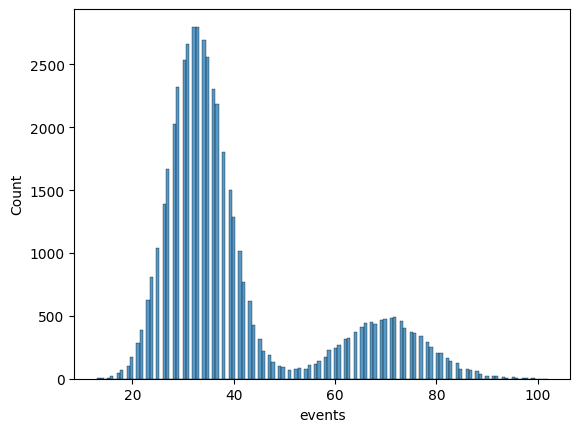

In [16]:
sns.histplot(data=task_2[task_2.group == 'test'], x='events')

<Axes: xlabel='events', ylabel='Count'>

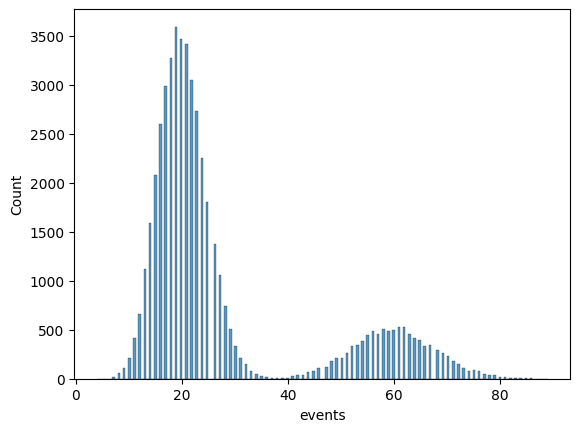

In [17]:
sns.histplot(data=task_2[task_2.group == 'control'], x='events')

In [18]:
# Считаем среднее, медиану и стандартное отклонение количества заказов по группе и сегменту

task_2.groupby(['group', 'segment'], as_index=False).agg({'events': ['mean', 'median', 'std']}).round(2)

group segment events             
                     mean median   std
0  control    high  59.97   60.0  7.81
1  control     low  20.03   20.0  4.47
2     test    high  69.94   70.0  8.40
3     test     low  33.03   33.0  5.72

Проверим влияние двух факторов — версии кнопки (**group**) и клиентского сегмента (**segment**) — на количество заказов. Также проверим, зависит ли эффект новой кнопки от сегмента. Для этого используем двухфакторный ANOVA.

In [19]:
# Выполняем двухфакторный ANOVA через statsmodels
manova = smf.ols("events ~ group + segment + group:segment", data=task_2).fit()
anova_lm(manova)

,df,sum_sq,mean_sq,F,PR(>F)
group,1.0,3.837195e+06,3.837195e+06,112031.864119,0.000000e+00
segment,1.0,2.362480e+07,2.362480e+07,689756.377485,0.000000e+00
group:segment,1.0,3.664244e+04,3.664244e+04,1069.823273,2.060261e-233
Residual,99996.0,3.424956e+06,3.425093e+01,NaN,NaN


In [20]:
# Повторяем двухфакторный ANOVA с помощью Pingouin
pg.anova(data=task_2, dv='events', between=['group', 'segment'], effsize='n2')

,Source,SS,DF,MS,F,p_unc,n2
0,group,3.837195e+06,1.0,3.837195e+06,112031.864119,0.000000e+00,0.124086
1,segment,2.362480e+07,1.0,2.362480e+07,689756.377484,0.000000e+00,0.763973
2,group * segment,3.664244e+04,1.0,3.664244e+04,1069.823273,2.060261e-233,0.001185
3,Residual,3.424956e+06,99996.0,3.425093e+01,NaN,NaN,NaN


**Что показывают результаты ANOVA:**

- Версия кнопки (**group**) статистически значимо связана с количеством заказов.
- Клиентский сегмент (**segment**) также статистически значимо связан с количеством заказов.
- Есть статистически значимое взаимодействие между версией кнопки и сегментом: эффект новой кнопки отличается для high и low.

При этом взаимодействие объясняет около **1% вариации** показателя (partial η² = 0.0106). То есть различие в эффекте между сегментами есть, но его вклад в общую вариативность показателя сравнительно небольшой.

<Axes: xlabel='group', ylabel='events'>

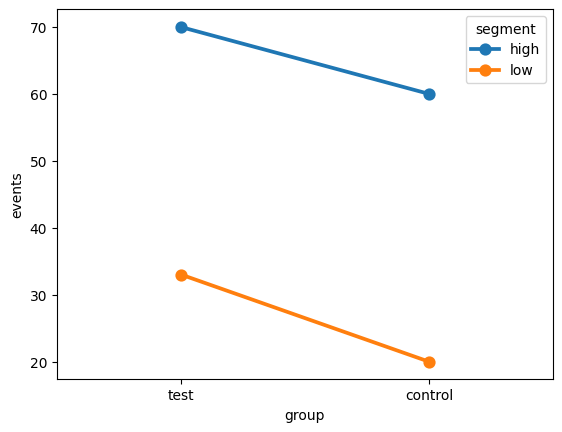

In [21]:
# Визуализируем количество заказов по версии кнопки и клиентскому сегменту
sns.pointplot(data=task_2, x='group', y='events', hue='segment')

In [22]:
# Сравниваем пары групп с помощью теста Тьюки
task_2['combination'] = task_2.group + "\\" + task_2.segment
task_2.head()

,id,group,segment,events,combination
0,83440,test,high,78.0,test\high
1,96723,test,high,71.0,test\high
2,68719,test,high,80.0,test\high
3,50399,test,high,80.0,test\high
4,95613,test,high,78.0,test\high


In [23]:
pg.pairwise_tukey(data=task_2, dv='events', between='combination')

,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges
0,control\high,control\low,59.970800,20.031575,39.939225,0.065432,610.391461,1.010172e-10,7.521612
1,control\high,test\high,59.970800,69.938500,-9.967700,0.082766,-120.432523,1.010172e-10,-1.228989
2,control\high,test\low,59.970800,33.025925,26.944875,0.065432,411.798717,1.010172e-10,4.350026
3,control\low,test\high,20.031575,69.938500,-49.906925,0.065432,-762.727892,1.010172e-10,-9.091140
4,control\low,test\low,20.031575,33.025925,-12.994350,0.041383,-314.002699,1.010172e-10,-2.530414
5,test\high,test\low,69.938500,33.025925,36.912575,0.065432,564.135148,1.010172e-10,5.814008


**Итог по тесту:** новая версия кнопки показывает большее среднее количество заказов, чем текущая, в обоих сегментах.

По среднему значению **events**:
- в сегменте **high** — прирост около **10 заказов**;
- в сегменте **low** — прирост около **13 заказов**.

Статистический тест подтверждает различия между вариантами. При интерпретации результата также учитываем, что эффект новой кнопки отличается между сегментами.